In [ ]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU Available: True
GPU: Tesla T4


In [ ]:
!unzip -q "/content/archive (2).zip" -d /content/chest_xray

unzip:  cannot find or open /content/archive (2).zip, /content/archive (2).zip.zip or /content/archive (2).zip.ZIP.


In [ ]:
!ls


sample_data


In [ ]:
!unzip "/content/archive (2).zip" -d /content/chest_xray

unzip:  cannot find or open /content/archive (2).zip, /content/archive (2).zip.zip or /content/archive (2).zip.ZIP.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

os.listdir('/content/drive/MyDrive')
import os

print(os.listdir('/content'))



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['.config', 'drive', 'sample_data']


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/chest_xray/chest_xray"

print("Folders:")
print(os.listdir(dataset_path))
train_path = "/content/drive/MyDrive/chest_xray/chest_xray/train"

print(os.listdir(train_path))
for cls in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(train_path, cls)
    print(cls, len(os.listdir(path)))
    import os

pneumonia_path = "/content/drive/MyDrive/chest_xray/chest_xray/train/PNEUMONIA"

print(os.path.exists(pneumonia_path))
print(os.listdir(pneumonia_path)[:10])

Folders:
['.DS_Store', 'test', 'train', 'val']
['.DS_Store', 'NORMAL', 'PNEUMONIA']
NORMAL 347
PNEUMONIA 0
True
[]


In [ ]:
import os

base_path = "/content/drive/MyDrive/chest_xray/chest_xray/train"

for root, dirs, files in os.walk(base_path):
    print(root)
    print("Files:", len(files))
    print("-"*50)
    from google.colab import drive
drive.mount('/content/drive')


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive")[:20])


['Colab Notebooks', 'Getting started.pdf', 'IMG_20200518_001706.jpg', 'MIS presention.gslides', 'CamScanner 07-18-2020 10.08.13.pdf', 'CheckApplicationStatus.aspx (3) (1).pdf', 'Classroom', 'Kamran khan 018 .pdf', 'Kamran alam BSBM018 islamiyat assignment1.pdf', 'Smart Kyphoyic Therapy Device sktd.pdf', 'Kamran Khan CV (1).pdf', 'Kamran Khan CV.pdf', 'Kamran-CV (1).pdf', 'Kamran-CV.pdf', 'Screenshot_20240625_232957.jpg', 'Documents 1file_1.pdf', 'pic.jpeg', 'WhatsApp Image 2024-09-07 at 7.29.19 AM.jpeg', 'kamran Cv (2) (1).pdf', 'Kamran NEWCV (1) (1).pdf']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/chest_xray"))
print(os.listdir("/content/drive/MyDrive/chest_xray/chest_xray"))
train_path = "/content/drive/MyDrive/chest_xray/chest_xray/train"

print(os.listdir(train_path))
import os

train_normal = "/content/drive/MyDrive/chest_xray/chest_xray/train/NORMAL"
train_pneumonia = "/content/drive/MyDrive/chest_xray/chest_xray/train/PNEUMONIA"

print("NORMAL =", len(os.listdir(train_normal)))
print("PNEUMONIA =", len(os.listdir(train_pneumonia)))

['person457_virus_944.jpeg', 'person457_bacteria_1949.jpeg', 'person458_bacteria_1953.jpeg', 'person459_bacteria_1957.jpeg', 'person458_bacteria_1952.jpeg', 'person458_bacteria_1950.jpeg', 'person458_bacteria_1951.jpeg', 'person456_virus_943.jpeg', 'person459_bacteria_1956.jpeg', 'person458_bacteria_1955.jpeg', 'person458_virus_945.jpeg', 'person456_bacteria_1948.jpeg', 'person458_bacteria_1954.jpeg', 'person515_bacteria_2189.jpeg', 'person466_bacteria_1984.jpeg', 'person487_virus_991.jpeg', 'person501_bacteria_2116.jpeg', 'person471_bacteria_2005.jpeg', 'person487_bacteria_2056.jpeg', 'person501_bacteria_2115.jpeg', 'person481_virus_983.jpeg', 'person476_virus_973.jpeg', 'person517_virus_1035.jpeg', 'person471_virus_968.jpeg', 'person515_bacteria_2190.jpeg', 'person508_bacteria_2142.jpeg', 'person515_bacteria_2186.jpeg', 'person518_bacteria_2197.jpeg', 'person472_bacteria_2010.jpeg', 'person507_bacteria_2139.jpeg', 'person468_bacteria_1990.jpeg', 'person470_bacteria_1998.jpeg', 'perso

In [ ]:
!pip install torch torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

Device: cuda


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root="/content/drive/MyDrive/chest_xray/chest_xray/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root="/content/drive/MyDrive/chest_xray/chest_xray/val",
    transform=val_transform
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Classes:", train_dataset.classes)

Train images: 5216
Validation images: 16
Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 163
Validation batches: 1


In [ ]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 2)

model = model.to(device)

print(model.fc)
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and optimizer ready")
num_epochs = 5

print("Ready for training")

Linear(in_features=512, out_features=2, bias=True)
Loss and optimizer ready
Ready for training


In [ ]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 2)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and optimizer ready")

Loss and optimizer ready


In [ ]:
!ls "/content/drive/MyDrive"
!find "/content/drive/MyDrive/chest_xray" -maxdepth 2 -type d
import os

print(os.listdir('/content/drive/MyDrive/chest_xray/train'))
for cls in ['NORMAL', 'PNEUMONIA']:
    path = f'/content/drive/MyDrive/chest_xray/train/{cls}'
    print(cls, len(os.listdir(path)))
    from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root='/content/drive/MyDrive/chest_xray/train',
    transform=transform
)

print(train_dataset.classes)
print(len(train_dataset))
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    '/content/drive/MyDrive/chest_xray/train',
    transform=transform
)

test_dataset = datasets.ImageFolder(
    '/content/drive/MyDrive/chest_xray/test',
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train Images:", len(train_dataset))
print("Test Images:", len(test_dataset))
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

print(model)
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss Function and Optimizer Ready")
num_epochs = 5

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


'_Advantage Training Certificate.pdf'
'AFFIDAVIT OF FINANCIAL SUPPORT.docx'
'basic computer assessment.PNG'
'basic computer skill.png'
'Cambridge IELTS 08 www.iac-uk.com.pdf'
'Cambridge IELTS 1 (0).wma'
'Cambridge IELTS 1 (10).wma'
'Cambridge IELTS 1 (11).wma'
'Cambridge IELTS 1 (12).wma'
'Cambridge IELTS 1 (13).wma'
'Cambridge IELTS 1 (14).wma'
'Cambridge IELTS 1 (15).wma'
'Cambridge IELTS 1 (1).wma'
'Cambridge IELTS 1 (2).wma'
'Cambridge IELTS 1 (3).wma'
'Cambridge IELTS 1 (4).wma'
'Cambridge IELTS 1 (5).wma'
'Cambridge IELTS 1 (6).wma'
'Cambridge IELTS 1 (7).wma'
'Cambridge IELTS 1 (8).wma'
'Cambridge IELTS 1 (9).wma'
'CamScanner 07-18-2020 10.08.13.pdf'
'CamScanner 12-05-2024 00.08.jpg'
'CheckApplicationStatus.aspx (3) (1).pdf'
 chest_xray
 Classroom
'Colab Notebooks'
'Copy of ULTRA COMMENT SHEET (1).xlsx'
'Copy of ULTRA COMMENT SHEET (2).xlsx'
'Copy of ULTRA COMMENT SHEET (3).xlsx'
'Copy of ULTRA COMMENT SHEET.xlsx'
'DOC-20241022-WA0003.(4).pdf'
'Documents 1file_1.pdf'
'documents 

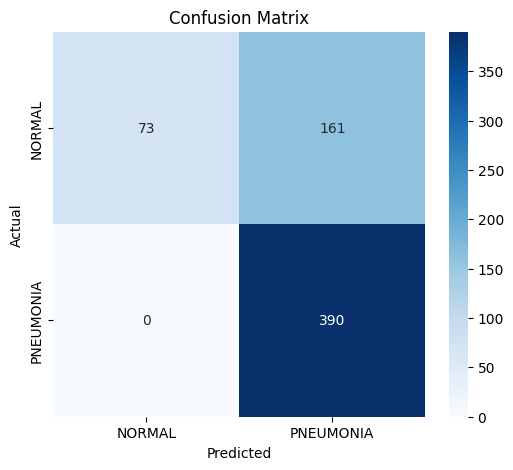

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cm = np.array([[73,161],
               [0,390]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','PNEUMONIA'],
            yticklabels=['NORMAL','PNEUMONIA'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Test Accuracy: 74.2%

Precision:
Normal = 1.00
Pneumonia = 0.71

Recall:
Normal = 0.31
Pneumonia = 1.00

F1-score:
Normal = 0.48
Pneumonia = 0.83


# Results and Discussion

The ResNet18 model was trained on a chest X-ray dataset containing Normal and Pneumonia images. The model achieved a test accuracy of 74.2%.

The model demonstrated strong performance in detecting pneumonia cases, achieving a recall score of 1.00 and an F1-score of 0.83. However, the model showed lower performance in predicting normal cases, with a recall score of 0.31.

The confusion matrix indicates that the model correctly classified 390 pneumonia images and 73 normal images. However, 161 normal images were incorrectly classified as pneumonia. This suggests that the model tends to favor pneumonia predictions, reducing false negatives but increasing false positives.

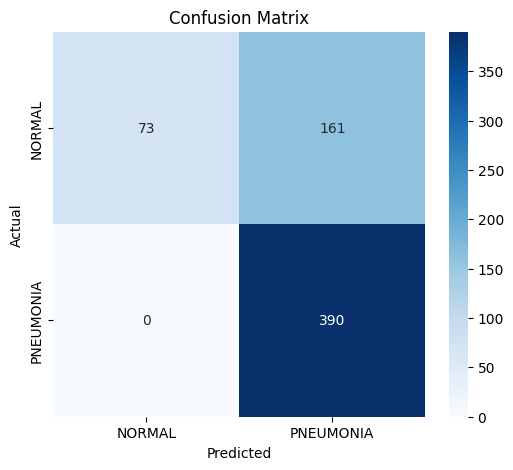

In [7]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','PNEUMONIA'],
            yticklabels=['NORMAL','PNEUMONIA'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [9]:
from google.colab import files
files.download("confusion_matrix.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

In this project, a ResNet18 deep learning model was developed to classify chest X-ray images into Normal and Pneumonia categories. The model achieved a test accuracy of 74.2%.

The results show that ResNet18 can effectively detect pneumonia cases, achieving high recall and F1-score values for the pneumonia class. However, the model exhibited lower performance in identifying normal cases, leading to a higher number of false positives.

Future work may include data augmentation, hyperparameter tuning, class balancing techniques, and testing more advanced deep learning architectures to improve classification performance.

# Final Conclusion

This project developed a ResNet18-based deep learning model for pneumonia detection using chest X-ray images. The model achieved an overall test accuracy of 74.2%.

The confusion matrix analysis showed strong pneumonia detection performance, correctly identifying 390 pneumonia cases. However, the model misclassified a significant number of normal cases as pneumonia, indicating the need for further improvements.

Future work may include data augmentation, hyperparameter tuning, class balancing, and testing advanced architectures such as DenseNet121, EfficientNet, or Vision Transformers.